# 01 — EDA & Baseline (Conversion Rate Challenge)

Objectif : comprendre le dataset, préparer les features et entraîner une **baseline** (métrique principale : **F1-score**).

In [7]:
# --- Imports de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Visualisations (optionnel)
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (8,5)
mpl.rcParams['axes.grid'] = True

# ML
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

DATA_DIR = Path('.')
TRAIN_FILE = next((p for p in [DATA_DIR/'data_train.csv', DATA_DIR/'conversion_data_train.csv'] if p.exists()), None)
assert TRAIN_FILE is not None, "Aucun fichier data_train.csv trouvé (essayé: data_train.csv / conversion_data_train.csv)"
print("-> Chargement:", TRAIN_FILE)
df = pd.read_csv(TRAIN_FILE)
print(df.shape)
df.head()


-> Chargement: conversion_data_train.csv
(284580, 6)


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


## Aperçu / Qualité des données

In [15]:
# Types, NA, duplicats
display(df.info())
display(df.describe(include='all').T)
display(df.isna().sum().sort_values(ascending=False))

# Distribution de la cible
TARGET = 'converted'
print("TARGET =", TARGET)
df[TARGET].value_counts(normalize=True)

# Séparation X / y
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,284580,4,US,160124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,284580.0,NaN,NaN,NaN,30.564203,8.266789,17.0,24.0,30.0,36.0,123.0
new_user,284580.0,NaN,NaN,NaN,0.685452,0.464336,0.0,0.0,1.0,1.0,1.0
source,284580,3,Seo,139477,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_pages_visited,284580.0,NaN,NaN,NaN,4.873252,3.341995,1.0,2.0,4.0,7.0,29.0
converted,284580.0,NaN,NaN,NaN,0.032258,0.176685,0.0,0.0,0.0,0.0,1.0


country                0
age                    0
new_user               0
source                 0
total_pages_visited    0
converted              0
dtype: int64

TARGET = converted


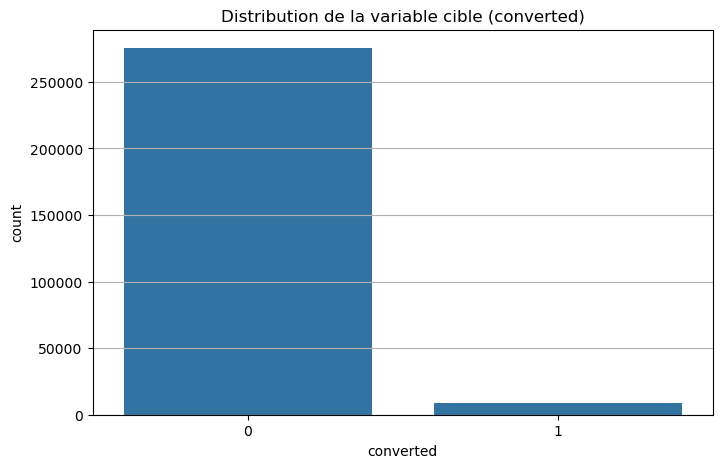

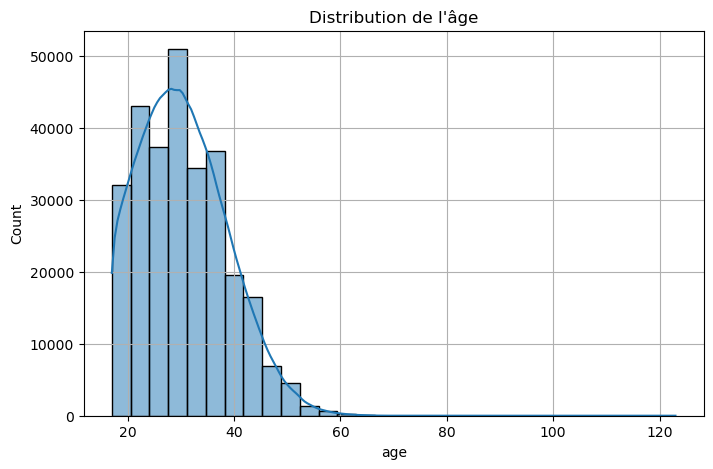

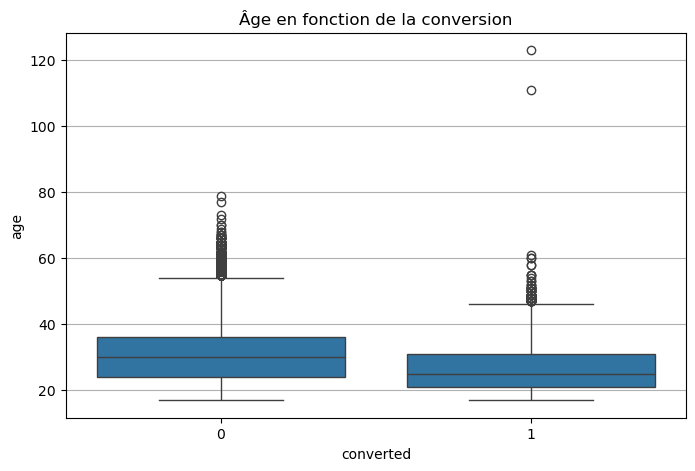

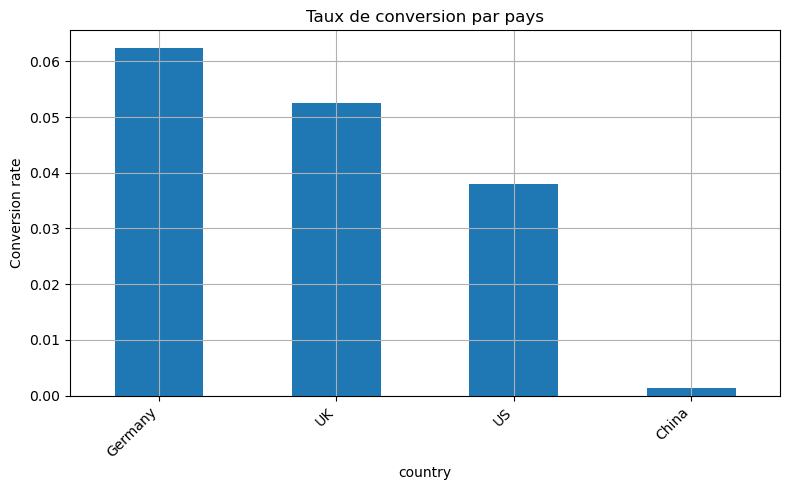

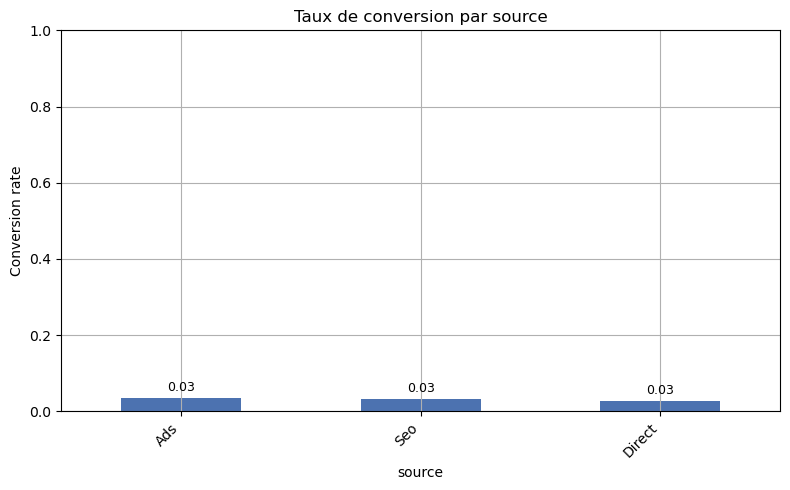

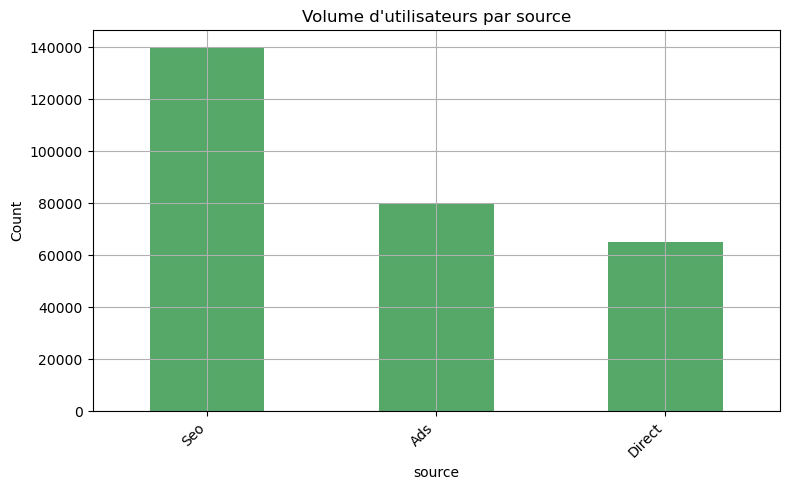

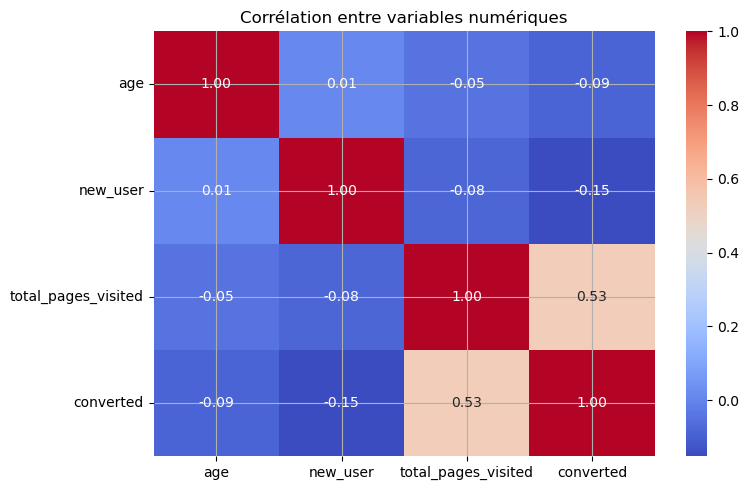

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Distribution de la cible
sns.countplot(x=y)
plt.title("Distribution de la variable cible (converted)")
plt.show()

# 2. Histogramme de l’âge

sns.histplot(df['age'], bins=30, kde=True)
plt.title("Distribution de l'âge")
plt.show()

# 3. Boxplot âge vs conversion

sns.boxplot(x=y, y=df['age'])
plt.title("Âge en fonction de la conversion")
plt.show()

# 4. Taux de conversion par pays (si 'country' existe)

conv_rate_country = df.groupby('country')[TARGET].mean().sort_values(ascending=False)
conv_rate_country.plot(kind='bar')
plt.title("Taux de conversion par pays")
plt.ylabel("Conversion rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4b. Taux de conversion par source (si 'source' existe)

conv_rate_source = df.groupby('source')[TARGET].mean().sort_values(ascending=False)
ax = conv_rate_source.plot(kind='bar', color='#4C72B0')
plt.title("Taux de conversion par source")
plt.ylabel("Conversion rate")
plt.ylim(0, 1)  # taux entre 0 et 1
plt.xticks(rotation=45, ha='right')
# Annoter les barres avec la valeur
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords='offset points')
plt.tight_layout()
plt.show()


counts = df['source'].value_counts()
counts.plot(kind='bar', color='#55A868')
plt.title("Volume d'utilisateurs par source")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Heatmap corrélations (numériques)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) >= 2:
    num_corr = df[num_cols].corr()
    sns.heatmap(num_corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Corrélation entre variables numériques")
    plt.tight_layout()
    plt.show()



## Détection auto des variables numériques et catégorielles

In [ ]:


# Cast automatiques pour améliorer robustesse
for col in X.select_dtypes(include='object').columns:
    # Tenter de parser en nombre sinon laisser en object
    try:
        X[col] = pd.to_numeric(X[col])
    except Exception:
        pass

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Num cols:", num_cols[:10], "...", len(num_cols))
print("Cat cols:", cat_cols[:10], "...", len(cat_cols))


Num cols: ['age', 'new_user', 'total_pages_visited'] ... 3
Cat cols: ['country', 'source'] ... 2


## Train/Test split (stratifié)

Train F1: 0.5079
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    220320
           1       0.35      0.94      0.51      7344

    accuracy                           0.94    227664
   macro avg       0.67      0.94      0.74    227664
weighted avg       0.98      0.94      0.95    227664



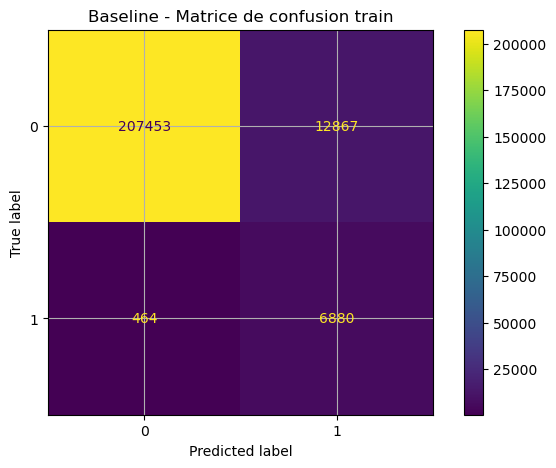

Test F1: 0.5131
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     55080
           1       0.35      0.95      0.51      1836

    accuracy                           0.94     56916
   macro avg       0.68      0.94      0.74     56916
weighted avg       0.98      0.94      0.95     56916



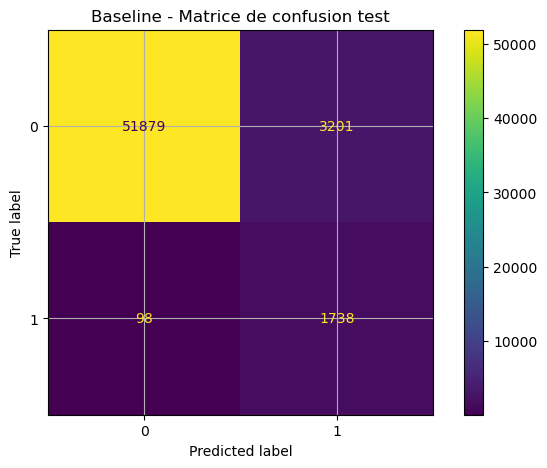

In [26]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipelines de prétraitement
num_pipe = Pipeline([("scaler", StandardScaler(with_mean=False))])  # with_mean=False pour compat sparse
cat_pipe = Pipeline([("ohe", OneHotEncoder(handle_unknown='ignore'))])

preproc = ColumnTransformer(
    [("num", num_pipe, num_cols),
     ("cat", cat_pipe, cat_cols)],
    remainder='drop',
)

baseline = Pipeline([
    ("preproc", preproc),
    ("clf", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

baseline.fit(X_tr, y_tr)

y_pred_tr = baseline.predict(X_tr)
f1_train=f1_score(y_tr, y_pred_tr)
print("Train F1:", round(f1_train, 4))
print(classification_report(y_tr, y_pred_tr))

ConfusionMatrixDisplay(confusion_matrix(y_tr, y_pred_tr)).plot()
plt.title("Baseline - Matrice de confusion train")
plt.show()




y_pred = baseline.predict(X_te)
f1 = f1_score(y_te, y_pred)
print("Test F1:", round(f1, 4))

print(classification_report(y_te, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred)).plot()
plt.title("Baseline - Matrice de confusion test")
plt.show()


### Notes rapides
- **class_weight='balanced'** pour compenser un éventuel déséquilibre de classes.
- Le **seuil 0.5** est utilisé par défaut ici ; on l’optimisera dans le notebook 2.